# work in progress external data

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import time


## events

In [9]:
!ls ../data/external

Verbraucherpreisindex.csv
_repo_intake_review_NON_FINAL
einwohnerstatistik-31.12.2025.csv
event_data.csv
football.csv
oil_price.csv
stac-statjahrbuch-2024.pdf


In [10]:
events = pd.read_csv('../data/external/event_data.csv', sep=';')

events.info()
print('--'*20)
display(events.sample(8))
print('Count Events:', events.event.nunique())
print('Events:', events.event.unique().tolist())

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   date    49 non-null     str  
 1   event   49 non-null     str  
dtypes: str(2)
memory usage: 2.2 KB
----------------------------------------


,date,event
3,2025-09-21,Stadtfest
42,2026-03-09,EUREGIO Wirtschaftsschau 2026
10,2025-03-22,EUREGIO Wirtschaftsschau
12,2025-03-24,EUREGIO Wirtschaftsschau
23,2025-06-27,CHIO Aachen
36,2026-03-25,vocatium Aachen
45,2026-03-12,EUREGIO Wirtschaftsschau 2026
11,2025-03-23,EUREGIO Wirtschaftsschau


Count Events: 7
Events: ['Stadtfest', 'WeinAachen', 'EUREGIO Wirtschaftsschau', 'Karrieretag Aachen', 'vocatium Aachen', 'CHIO Aachen', 'EUREGIO Wirtschaftsschau 2026']


In [11]:
# mapping zipcode

mapping = {
    "Stadtfest": "52062",
    "WeinAachen": "52062",
    "EUREGIO Wirtschaftsschau": "52070",
    "Karrieretag Aachen": "52062",
    "vocatium Aachen": "52062",
    "CHIO Aachen": "52070",
    "EUREGIO Wirtschaftsschau 2026": "52070",
}

events['zipcode'] = events.event.map(mapping)
display(events.sort_values('date'))
events.zipcode.unique()

,date,event,zipcode
8,2025-03-15,WeinAachen,52062
9,2025-03-16,WeinAachen,52062
10,2025-03-22,EUREGIO Wirtschaftsschau,52070
11,2025-03-23,EUREGIO Wirtschaftsschau,52070
12,2025-03-24,EUREGIO Wirtschaftsschau,52070
13,2025-03-25,EUREGIO Wirtschaftsschau,52070
14,2025-03-26,EUREGIO Wirtschaftsschau,52070
15,2025-03-27,EUREGIO Wirtschaftsschau,52070
16,2025-03-28,EUREGIO Wirtschaftsschau,52070
17,2025-03-29,EUREGIO Wirtschaftsschau,52070


<ArrowStringArray>
['52062', '52070']
Length: 2, dtype: str

In [12]:
# dtpyes change
events['date'] = pd.to_datetime(events['date'])
events['event'] = events['event'].astype('category')
events['zipcode'] = events['zipcode'].astype('category')

print(events.info())
events.head()

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     49 non-null     datetime64[us]
 1   event    49 non-null     category      
 2   zipcode  49 non-null     category      
dtypes: category(2), datetime64[us](1)
memory usage: 822.0 bytes
None


,date,event,zipcode
0,2025-09-18,Stadtfest,52062
1,2025-09-19,Stadtfest,52062
2,2025-09-20,Stadtfest,52062
3,2025-09-21,Stadtfest,52062
4,2025-09-22,Stadtfest,52062


In [13]:
# write to disc
events.to_parquet('../data/processed/events_transformed.parquet', index=False, )

## football

In [24]:
football_raw = pd.read_csv('../data/external/football.csv', sep=',', index_col=0)
# scheinen auswärtsspiele zu sein
display(football_raw.sort_values('matchDateTime').head(2))
# plz stadion 52070
football = football_raw[['matchDateTime', 'team2.shortName' ]]
football['zipcode'] = 52070

,matchID,matchDateTime,timeZoneID,leagueId,leagueName,leagueSeason,leagueShortcut,matchDateTimeUTC,lastUpdateDateTime,matchIsFinished,...,team1.teamIconUrl,team1.teamGroupName,team2.teamId,team2.teamName,team2.shortName,team2.teamIconUrl,team2.teamGroupName,location.locationID,location.locationCity,location.locationStadium
14,78269,2025-08-09T14:00:00,W. Europe Standard Time,4857,3. Liga 2025/2026,2025,bl3,2025-08-09T12:00:00Z,2025-08-10T15:13:35.52,True,...,https://upload.wikimedia.org/wikipedia/commons...,NaN,2396,TSG 1899 Hoffenheim II,TSG 1899 Hoffenheim II,https://upload.wikimedia.org/wikipedia/commons...,NaN,NaN,NaN,NaN
24,78281,2025-08-23T14:00:00,W. Europe Standard Time,4857,3. Liga 2025/2026,2025,bl3,2025-08-23T12:00:00Z,2025-08-23T17:19:52.08,True,...,https://upload.wikimedia.org/wikipedia/commons...,NaN,125,TSV 1860 München,1860 München,https://upload.wikimedia.org/wikipedia/commons...,NaN,NaN,NaN,NaN


In [25]:
football.head()

,matchDateTime,team2.shortName,zipcode
14,2025-08-09T14:00:00,TSG 1899 Hoffenheim II,52070
24,2025-08-23T14:00:00,1860 München,52070
46,2025-09-13T16:30:00,SSV Ulm 1846,52070
64,2025-09-20T14:00:00,Mannheim,52070
84,2025-09-30T19:00:00,Aue,52070


## oil price

In [26]:
oil_price = pd.read_csv('../data/external/oil_price.csv')
oil_price = oil_price[2:].rename(columns={'Price': 'Date'})
oil_price.info()
oil_price.Date.max()
oil_price.head()
print('std:', oil_price.High.astype('float64').std())
# volume?

<class 'pandas.DataFrame'>
RangeIndex: 354 entries, 2 to 355
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Date    354 non-null    str  
 1   Close   354 non-null    str  
 2   High    354 non-null    str  
 3   Low     354 non-null    str  
 4   Open    354 non-null    str  
 5   Volume  354 non-null    str  
dtypes: str(6)
memory usage: 45.0 KB
std: 14.40105795094324


In [27]:
oil_price['Date'] = pd.to_datetime(oil_price['Date'])
oil_price['High'] = oil_price['High'].astype('float64')
oil_price.head(2)

,Date,Close,High,Low,Open,Volume
2,2025-01-02,73.12999725341797,73.730003,71.79000091552734,71.8499984741211,306498
3,2025-01-03,73.95999908447266,74.349998,72.69999694824219,73.12999725341797,296040


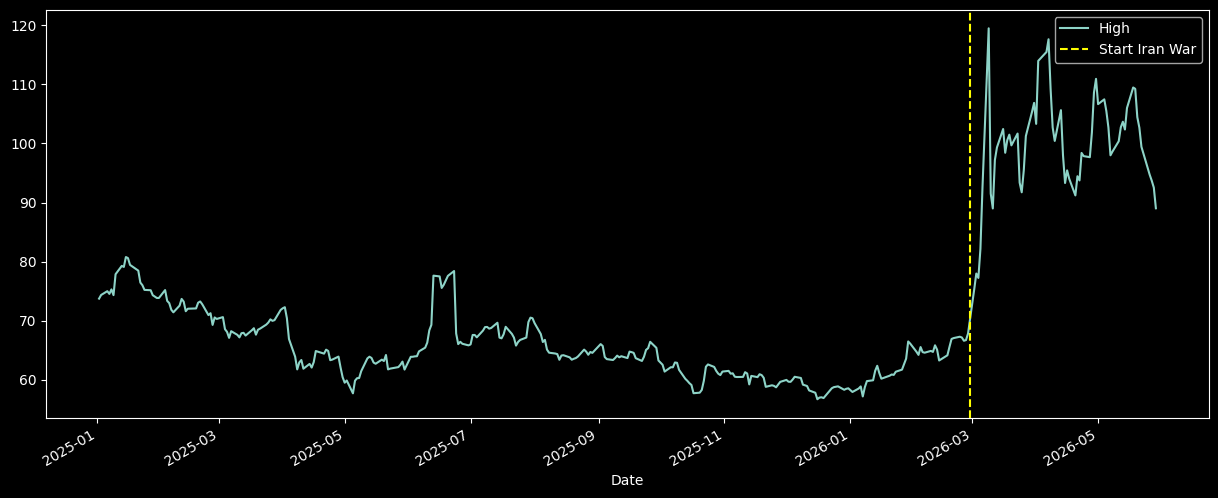

In [28]:
plt.style.use('dark_background')
oil_price.plot(kind='line', x='Date', y='High', figsize=(15,6))
plt.axvline('2026-02-28', linestyle="--", color='yellow', label='Start Iran War')
plt.legend()
plt.show()

In [30]:
##  test test
df = pd.read_parquet('../data/processed/02_df_cleaned.parquet', engine='pyarrow')
df.head()

,store_id,item_id,date,category_name,sold_quantity,revenue,zipcode,holiday_name,holiday_type,wind_dir,...,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_28,rolling_std_28,rolling_sum_7,rolling_sum_28,expanding_mean,price_rounded
0,0,5,2025-02-01,Kuchen,1.0,10.50,52062,no_holiday,no_holiday,SE,...,0.142857,0.377964,0.142857,0.363137,0.107143,0.314970,1.0,3.0,0.001224,10.5
1,0,5,2025-03-15,Kuchen,1.0,10.50,52062,no_holiday,no_holiday,NE,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.001604,10.5
2,0,5,2025-03-29,Kuchen,1.0,10.50,52062,no_holiday,no_holiday,NNW,...,0.000000,0.000000,0.071429,0.267261,0.035714,0.188982,0.0,1.0,0.001994,10.5
3,0,5,2025-05-17,Kuchen,1.0,11.25,52062,no_holiday,no_holiday,N,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.002347,11.2
4,0,5,2025-05-24,Kuchen,1.0,11.25,52062,no_holiday,no_holiday,SSW,...,0.142857,0.377964,0.071429,0.267261,0.035714,0.188982,1.0,1.0,0.002731,11.2


In [31]:
rolls = df[(df.category_name == 'Brötchen') & (df.date > '2025-06-01')]
rolls_by_date = rolls.groupby(['category_name', 'date'])['revenue'].agg(['sum', 'mean', 'std']).reset_index().sort_values('date')
display(rolls_by_date.head(2))
for c in df.category_name.unique():
    print(c)


,category_name,date,sum,mean,std
0,Brötchen,2025-06-02,67002.601562,35.830269,48.237026
1,Brötchen,2025-06-03,62555.464844,33.362915,45.045677


Kuchen
Snack
Brot
Brötchen
Feinbäckerei
Kaltgetränke 19%
Heißgetränke
Angebot Brot
Printen/Kekse
Konditorei
Snack Belag
Angebot Snack
Angebot Brötchen 
Angebot Gastro
Kaltgetränke 7%
Angebot Feinbäckerei
Angebot Kuchen
Angebot Heißgetränke
Eigerichte
Printen Waage
Frühstücke
Gastro Gerichte
Angebot Konditorei
Brotwaage


In [32]:
# plot oilprice vs revenue brötchen
oil_price_2026 = oil_price[oil_price.Date > '2025-06-01']
oil_price_2026

,Date,Close,High,Low,Open,Volume
105,2025-06-02,62.52000045776367,63.880001,61.060001373291016,61.11000061035156,403580
106,2025-06-03,63.40999984741211,63.889999,62.400001525878906,63.02000045776367,291260
107,2025-06-04,62.849998474121094,63.959999,62.16999816894531,63.36000061035156,321128
108,2025-06-05,63.369998931884766,63.980000,62.5,62.7599983215332,232423
109,2025-06-06,64.58000183105469,64.800003,62.81999969482422,63.33000183105469,310133
...,...,...,...,...,...,...
351,2026-05-22,96.5999984741211,99.430000,94.7300033569336,98.0,261142
352,2026-05-26,93.88999938964844,94.699997,89.41000366210938,93.87999725341797,358867
353,2026-05-27,88.68000030517578,93.690002,87.7699966430664,93.38999938964844,290948
354,2026-05-28,88.9000015258789,92.519997,87.11000061035156,89.11000061035156,235145


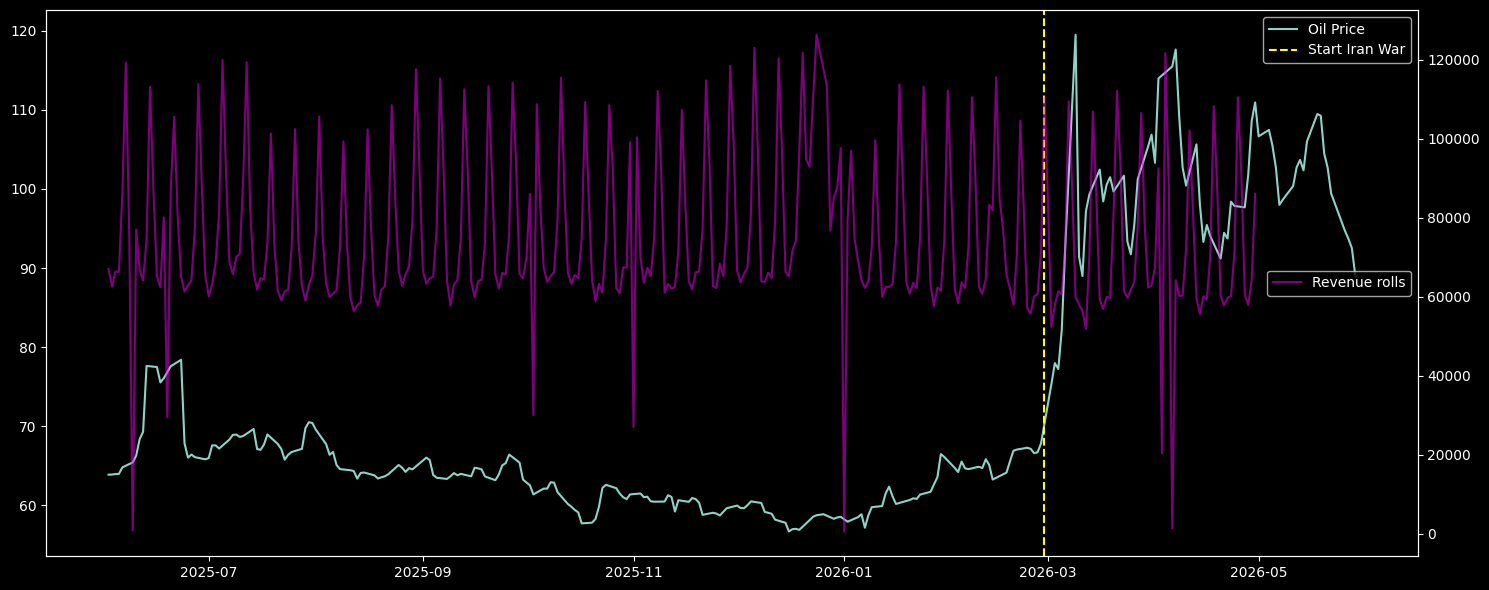

In [33]:
fig, ax = plt.subplots(figsize=(15,6))

ax.plot(oil_price_2026.Date, oil_price_2026.High, label='Oil Price')
ax.axvline(pd.to_datetime('2026-02-28'), linestyle="--", color='yellow', label='Start Iran War')

# 2nd y axis
ax2 = ax.twinx()
ax2.plot(rolls_by_date.date, rolls_by_date['sum'], label='Revenue rolls', color='magenta', alpha=0.5)

ax.legend()
ax2.legend(loc=5)
plt.tight_layout()
plt.show()

## population statistics / opendata aachen


In [34]:
# zipcode mapping sourrounding area

zipcode_surrounding = {
    "52224": "Stolberg (Rheinland)",
    "52134": "Herzogenrath",
    "52222": "Stolberg (Rheinland)",
    "52379": "Langerwehe",
    "52146": "Würselen",
    "52249": "Eschweiler",
    "52477": "Alsdorf",
    "52223": "Stolberg (Rheinland)",
    "52499": "Baesweiler",
    "52428": "Jülich",
    "52152": "Simmerath",
    "52531": "Übach-Palenberg",
    "52159": "Roetgen",
    "52156": "Monschau",
    "52382": "Niederzier",
    "52351": "Düren"
}

set(zipcode_surrounding.values())

{'Alsdorf',
 'Baesweiler',
 'Düren',
 'Eschweiler',
 'Herzogenrath',
 'Jülich',
 'Langerwehe',
 'Monschau',
 'Niederzier',
 'Roetgen',
 'Simmerath',
 'Stolberg (Rheinland)',
 'Würselen',
 'Übach-Palenberg'}

In [35]:
# load
pd.set_option('display.max_columns', None)
population_2025 = pd.read_csv('../data/external/einwohnerstatistik-31.12.2025.csv', sep=',', encoding='latin1')
population_2025.head()


,Bez,StatBezName,Pers_ insges,HW,NW,M,W,LD,VH,VW,GS,RK,EV,0-2,3-5,6-9,10-14,15-17,18-19,20-24,25-29,30-34,35-39,40-44,45-49,50-54,55-59,60-64,65-69,70-74,75-79,80-84,85-89,90um,Deutsch,Ausl
0,10.0,Markt,2834.0,2793.0,41.0,1618.0,1216.0,2161.0,468.0,74.0,131.0,799.0,323.0,31.0,29.0,25.0,37.0,17.0,70.0,630.0,679.0,372.0,177.0,114.0,95.0,85.0,87.0,95.0,78.0,64.0,45.0,44.0,40.0,20.0,1849.0,985.0
1,13.0,Theater,3259.0,3230.0,29.0,1910.0,1349.0,2480.0,564.0,72.0,143.0,809.0,336.0,47.0,26.0,32.0,38.0,23.0,115.0,784.0,686.0,380.0,230.0,129.0,102.0,87.0,107.0,123.0,101.0,69.0,71.0,57.0,41.0,11.0,1977.0,1282.0
2,14.0,Lindenplatz,4235.0,4205.0,30.0,2343.0,1892.0,3236.0,644.0,173.0,182.0,1230.0,508.0,40.0,44.0,52.0,61.0,36.0,114.0,905.0,968.0,489.0,243.0,162.0,112.0,126.0,158.0,146.0,119.0,112.0,92.0,83.0,109.0,64.0,2856.0,1379.0
3,15.0,St. Jakob,6590.0,6513.0,77.0,3690.0,2900.0,5088.0,1080.0,133.0,289.0,1945.0,846.0,103.0,73.0,88.0,87.0,66.0,181.0,1426.0,1561.0,868.0,396.0,265.0,212.0,195.0,242.0,252.0,191.0,143.0,105.0,61.0,52.0,23.0,4964.0,1626.0
4,16.0,Westpark,8583.0,8490.0,93.0,4707.0,3876.0,5895.0,2033.0,272.0,383.0,2475.0,1037.0,152.0,125.0,182.0,223.0,124.0,293.0,1438.0,1631.0,1005.0,547.0,393.0,341.0,314.0,379.0,349.0,342.0,222.0,156.0,147.0,145.0,75.0,6202.0,2381.0


In [36]:
# get municipal distric names
#population_2025.StatBezName.str.strip().unique().tolist()

# mapping list with zipcode (thanks CHatGPT)
district_zipcode = {
    'Markt': '52062',
    'Theater': '52062',
    'Lindenplatz': '52064',
    'St. Jakob': '52064',
    'Westpark': '52064',
    'Hanbruch': '52074',
    'Hörn': '52074',
    'Ponttor': '52062',
    'Hansemannplatz': '52070',
    'Soers': '52070',
    'Jülicher Str.': '52070',
    'Jülicher Straße': '52070',
    'Kalkofen': '52070',
    'Kaiserplatz': '52062',
    'Adalbertsteinweg': '52070',
    'Panneschopp': '52068',
    'Rothe Erde': '52068',
    'Trierer Str.': '52078',
    'Trierer Straße': '52078',
    'Frankenberg': '52066',
    'Forst': '52078',
    'Beverau': '52066',
    'Burtsch. Kurgarten': '52066',
    'Burtscheider Kurgarten': '52066',
    'Burtscheider Abtei': '52066',
    'Steinebrück': '52080',
    'Marschiertor': '52064',
    'Hangeweiher': '52074',
    'Brand': '52078',
    'Eilendorf': '52080',
    'Haaren': '52080',
    'Kornelimünster': '52076',
    'Oberforstbach': '52076',
    'Walheim': '52076',
    'Vaalserquartier': '52074',
    'Laurensberg': '52072',
    'Richterich': '52072',
    'STADT AACHEN': '52000',  # Sammelwert / ggf. NaN verwenden
}


# adding zipcode to data set
population_2025.insert(1, 'zipcode', population_2025.StatBezName.str.strip().map(district_zipcode), allow_duplicates=False)
population_2025.head()

,Bez,zipcode,StatBezName,Pers_ insges,HW,NW,M,W,LD,VH,VW,GS,RK,EV,0-2,3-5,6-9,10-14,15-17,18-19,20-24,25-29,30-34,35-39,40-44,45-49,50-54,55-59,60-64,65-69,70-74,75-79,80-84,85-89,90um,Deutsch,Ausl
0,10.0,52062,Markt,2834.0,2793.0,41.0,1618.0,1216.0,2161.0,468.0,74.0,131.0,799.0,323.0,31.0,29.0,25.0,37.0,17.0,70.0,630.0,679.0,372.0,177.0,114.0,95.0,85.0,87.0,95.0,78.0,64.0,45.0,44.0,40.0,20.0,1849.0,985.0
1,13.0,52062,Theater,3259.0,3230.0,29.0,1910.0,1349.0,2480.0,564.0,72.0,143.0,809.0,336.0,47.0,26.0,32.0,38.0,23.0,115.0,784.0,686.0,380.0,230.0,129.0,102.0,87.0,107.0,123.0,101.0,69.0,71.0,57.0,41.0,11.0,1977.0,1282.0
2,14.0,52064,Lindenplatz,4235.0,4205.0,30.0,2343.0,1892.0,3236.0,644.0,173.0,182.0,1230.0,508.0,40.0,44.0,52.0,61.0,36.0,114.0,905.0,968.0,489.0,243.0,162.0,112.0,126.0,158.0,146.0,119.0,112.0,92.0,83.0,109.0,64.0,2856.0,1379.0
3,15.0,52064,St. Jakob,6590.0,6513.0,77.0,3690.0,2900.0,5088.0,1080.0,133.0,289.0,1945.0,846.0,103.0,73.0,88.0,87.0,66.0,181.0,1426.0,1561.0,868.0,396.0,265.0,212.0,195.0,242.0,252.0,191.0,143.0,105.0,61.0,52.0,23.0,4964.0,1626.0
4,16.0,52064,Westpark,8583.0,8490.0,93.0,4707.0,3876.0,5895.0,2033.0,272.0,383.0,2475.0,1037.0,152.0,125.0,182.0,223.0,124.0,293.0,1438.0,1631.0,1005.0,547.0,393.0,341.0,314.0,379.0,349.0,342.0,222.0,156.0,147.0,145.0,75.0,6202.0,2381.0


In [37]:

population_2025_transformed = population_2025[['zipcode', 'Pers_ insges', 'Deutsch', 'Ausl']]
display(population_2025_transformed.sort_values('zipcode').head(2))
population_2025_transformed.info()

,zipcode,Pers_ insges,Deutsch,Ausl
34,52000,NaN,NaN,NaN
0,52062,2834.0,1849.0,985.0


<class 'pandas.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   zipcode       35 non-null     str    
 1   Pers_ insges  34 non-null     float64
 2   Deutsch       34 non-null     float64
 3   Ausl          34 non-null     float64
dtypes: float64(3), str(1)
memory usage: 1.4 KB


In [38]:
population_2025_transformed = population_2025_transformed.groupby('zipcode')[['Pers_ insges', 'Deutsch', 'Ausl']].sum()[1:].reset_index()

In [39]:
population_2025_transformed.head()

,zipcode,Pers_ insges,Deutsch,Ausl
0,52062,28632.0,17837.0,10795.0
1,52064,26434.0,18924.0,7510.0
2,52066,25742.0,20733.0,5009.0
3,52068,11292.0,5721.0,5571.0
4,52070,29784.0,19094.0,10690.0


In [40]:
# write to disc
population_2025_transformed.to_parquet('../data/processed/population_2025_transformed.parquet', index=False)

In [41]:
#e = pd.read_csv('external_data/_repo_intake_review_NON_FINAL/13111-01-03-5-B_05.csv', skip_prows==10).e.head()

## population / age groups

In [42]:
population_2025.head()

,Bez,zipcode,StatBezName,Pers_ insges,HW,NW,M,W,LD,VH,VW,GS,RK,EV,0-2,3-5,6-9,10-14,15-17,18-19,20-24,25-29,30-34,35-39,40-44,45-49,50-54,55-59,60-64,65-69,70-74,75-79,80-84,85-89,90um,Deutsch,Ausl
0,10.0,52062,Markt,2834.0,2793.0,41.0,1618.0,1216.0,2161.0,468.0,74.0,131.0,799.0,323.0,31.0,29.0,25.0,37.0,17.0,70.0,630.0,679.0,372.0,177.0,114.0,95.0,85.0,87.0,95.0,78.0,64.0,45.0,44.0,40.0,20.0,1849.0,985.0
1,13.0,52062,Theater,3259.0,3230.0,29.0,1910.0,1349.0,2480.0,564.0,72.0,143.0,809.0,336.0,47.0,26.0,32.0,38.0,23.0,115.0,784.0,686.0,380.0,230.0,129.0,102.0,87.0,107.0,123.0,101.0,69.0,71.0,57.0,41.0,11.0,1977.0,1282.0
2,14.0,52064,Lindenplatz,4235.0,4205.0,30.0,2343.0,1892.0,3236.0,644.0,173.0,182.0,1230.0,508.0,40.0,44.0,52.0,61.0,36.0,114.0,905.0,968.0,489.0,243.0,162.0,112.0,126.0,158.0,146.0,119.0,112.0,92.0,83.0,109.0,64.0,2856.0,1379.0
3,15.0,52064,St. Jakob,6590.0,6513.0,77.0,3690.0,2900.0,5088.0,1080.0,133.0,289.0,1945.0,846.0,103.0,73.0,88.0,87.0,66.0,181.0,1426.0,1561.0,868.0,396.0,265.0,212.0,195.0,242.0,252.0,191.0,143.0,105.0,61.0,52.0,23.0,4964.0,1626.0
4,16.0,52064,Westpark,8583.0,8490.0,93.0,4707.0,3876.0,5895.0,2033.0,272.0,383.0,2475.0,1037.0,152.0,125.0,182.0,223.0,124.0,293.0,1438.0,1631.0,1005.0,547.0,393.0,341.0,314.0,379.0,349.0,342.0,222.0,156.0,147.0,145.0,75.0,6202.0,2381.0


In [43]:
### hier weiter
population_2025.columns

age_groups_cols = ['zipcode', '0-2', '3-5', '6-9', '10-14',
       '15-17', '18-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49',
       '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80-84', '85-89',
       '90um']

age_groups = population_2025[age_groups_cols].groupby('zipcode').sum()[1:]  #.astype('category')

In [44]:
# write to disc
age_groups.to_parquet('../data/processed/age_groups_2025_transformed.parquet', index=True)

## population / matital status)

In [45]:
population_2025.columns

marital_status_cols = ['zipcode', 'LD', 'VH', 'VW', 'GS']

marital_status = population_2025[marital_status_cols].groupby('zipcode').sum()[1:]

In [46]:
# write to disc
marital_status.to_parquet('../data/processed/marital_status_transformed.parquet', index=True)

In [47]:
## play

s = "check, 123 and 4"
n =list(range(10))
l = []

# -----
for char in s.split(' '):
   l.append(char) if char.isnumeric() else None

print(''.join(l))
print('----')

# ---
nummern = ''
for i in range(len(s)):
    try:
        print(i, s[i], int(s[i]) in n)
        nummern += s[i]
    except:
        print(i, s[i], 'no number')
nummern

1234
----
0 c no number
1 h no number
2 e no number
3 c no number
4 k no number
5 , no number
6   no number
7 1 True
8 2 True
9 3 True
10   no number
11 a no number
12 n no number
13 d no number
14   no number
15 4 True


'1234'

## Employed population 2024 (!)

In [48]:
import camelot

#### employed by age

In [49]:
# social security employed 2024 -> by age ( < 25, 25-35, > 35, percentage)

# read table employed 2024 from pdf
employed_2024 = camelot.read_pdf('../data/external/stac-statjahrbuch-2024.pdf', flavor='network', pages='53, 54')

In [50]:
# make it a dataframe (table 1)
employed_2024_age = employed_2024[1].df[2:]
#df_employed_2024_age.head(3)

# change header

# create new header
#last_4 = df_employed_2024_age.iloc[1][3:].to_list()
#first_3 = ['dist_id', 'dist_name', 'unter_25']
#new_header = first_3 + last_4

new_header = ['dist_id', 'dist_name', '<25', '25-35', '>35', 'Total_share_working_age_population']

# apply new header
employed_2024_age.columns = new_header
employed_2024_age = employed_2024_age[2:]

# removing subtotals and last and not assigned values
subtotals = employed_2024_age.dist_name.str.startswith('Stadtbezirk')
employed_2024_age = employed_2024_age[~subtotals][:-2].reset_index(drop=True)

employed_2024_age.head()

,dist_id,dist_name,<25,25-35,>35,Total_share_working_age_population
0,10,Markt,233,622,426,"52,69%"
1,13,Theater,192,678,463,"48,86%"
2,14,Lindenplatz,273,858,562,"49,04%"
3,15,St. Jakob,471,1.515,981,"52,70%"
4,16,Westpark,471,1.591,1.458,"52,96%"


### employed by german vs. non-german

In [51]:
employed_2024_ger = employed_2024[0].df[1:]

In [52]:
employed_2024_ger.head()

,0,1,2,3,4,5,6
1,Statistischer Bezirk / Stadtbezirk,,gesamt,darunter,,,
2,,,,männlich,weiblich,Deutsche,Nicht-Deutsche
3,10,Markt,1.281,748,533,886,395
4,13,Theater,1.333,790,543,939,394
5,14,Lindenplatz,1.693,1.024,669,1.200,493


In [53]:
# create new header
#last_4 = df_employed_2024_ger.iloc[1][3:].to_list()
#first_3 = ['dist_id', 'dist_name', 'total']
#new_header = first_3 + last_4

new_header = ['dist_id', 'dist_name', 'total', 'male', 'female', 'german', 'non-german']

# apply new header
employed_2024_ger.columns = new_header
employed_2024_ger = employed_2024_ger[2:]
employed_2024_ger.head()

# removing subtotals and last and not assigned values
subtotals = employed_2024_ger.dist_name.str.startswith('Stadtbezirk')
employed_2024_ger = employed_2024_ger[~subtotals][:-2].reset_index(drop=True)


employed_2024_ger.head()

,dist_id,dist_name,total,male,female,german,non-german
0,10,Markt,1.281,748,533,886,395
1,13,Theater,1.333,790,543,939,394
2,14,Lindenplatz,1.693,1.024,669,1.200,493
3,15,St. Jakob,2.967,1.680,1.287,2.328,639
4,16,Westpark,3.520,2.013,1.507,2.649,871


### employed_transformed (merged)

In [54]:
# merge both table to one
employed_2024_tranformed = employed_2024_ger.merge(employed_2024_age, on=['dist_id', 'dist_name'], how='inner')

In [55]:
# adding zipcodes
employed_2024_tranformed['zipcode'] = employed_2024_tranformed.dist_name.map(district_zipcode)

In [56]:
# export as parquet file
employed_2024_tranformed.to_parquet('../data/processed/employed_2024_transformed.parquet', engine='pyarrow', index=False)

## Unemployed population 2024(!)

In [70]:
# social security UNemployed 2024

# read table employed 2024 from pdf
unemployed_2024 = camelot.read_pdf('../data/external/stac-statjahrbuch-2024.pdf', flavor='network', pages='55, 56')

In [71]:
# table unemployed 2024 sexes and ger vs. non-ger
unemployed_2024_ger = unemployed_2024[0].df[3:]
unemployed_2024_ger.head()

,0,1,2,3,4,5,6
3,10,Markt,100,61,39,55,45
4,13,Theater,108,65,43,63,45
5,14,Lindenplatz,171,102,69,100,71
6,15,St. Jakob,272,153,119,186,86
7,16,Westpark,333,182,151,197,136


In [72]:

new_header = ['dist_id', 'dist_name', 'total', 'male', 'female', 'german', 'non-german']

# apply new header
unemployed_2024_ger.columns = new_header
unemployed_2024_ger = unemployed_2024_ger
unemployed_2024_ger.head()

# removing subtotals and last and not assigned values
subtotals =unemployed_2024_ger.dist_name.str.startswith('Stadtbezirk')
unemployed_2024_ger = unemployed_2024_ger[~subtotals][:-2].reset_index(drop=True)

unemployed_2024_ger.head()

# to be continued
print('...unemployed 2024... to be continued')

...unemployed 2024... to be continued


## Competitors

In [ ]:
# funtion query overpass API

def get_osm_bakery_count(zipcode: str, retries: int = 8) -> int:
    '''
    - Queries the OSM overpass API to count all shop=bakery in the given zipcode area
    - Returns an interger with the total count of bakeries in the given zipcode area

    Param:
        zipcode: str
        the zipcode of the area you want to search for bakeries provided as str

        retries: int
        how many retry queries to the overpass server are send. overpass is very unstable and quickly
        reaches a RATE_LIMIT
    '''

    zipcode = str(zipcode).strip()
    
    url = "https://overpass-api.de/api/interpreter"

    headers = { 
        "User-Agent": "PLZ-Bakery-Counter/1.0 (contact: marcel_junior@hotmail.com)"
    }
    
    overpass_query = f'''
    [out:json][timeout:180];
    rel ["boundary"="postal_code"]["postal_code"="{zipcode}"];
    map_to_area->.plz_area;
    (
      nwr(area.plz_area)["shop"="bakery"];
    );
    out count;
    '''


    for i in range(retries):
        response = requests.post(url, data={'data':overpass_query}, headers=headers, timeout=180)
        
        bad_status_codes = [429, 500, 501, 502, 503, 504]
        
        if response.status_code in bad_status_codes:
            wait = 10 + i *5
            print(f"{response.status_code} → hard wait {wait}s")
            time.sleep(wait)
            continue


        # braucht man das?   check if status_code response is usefull (>= 400)
        try:
            response.raise_for_status()
            
        except requests.exceptions.HTTPError:
            return {
                'error': response.status_code,
                'text': response.text
            }
    
    
        # check for value errors in response
        try:
            result = response.json()
        except ValueError:
            return{
                'error': 'invalid json response',
                'text': response.text
            }
    
            
        bakery_count = int(result['elements'][0]['tags']['total'])

        return bakery_count




In [ ]:

zipcodes = df.zipcode.unique()
zipcodes

In [ ]:
# get competitors

competitors = {}

l = len(zipcodes)
i = 1

for z in zipcodes:
    print(f'{i}/{l}:\n')
    print(z)
    
    # filter df for current zipcode
    filtered = df[df.zipcode == z]

    # count unique stores within zipcode
    store_count = filtered['store_id'].nunique()

    # count all osm bakeries by zipcode
    osm_bakery_count = get_osm_bakery_count(z)

    # calculate competitors count
    competitors_count = osm_bakery_count - store_count

    # print results
    print(f'''
    Stores: \t\t{store_count}
    Competitors:  \t{competitors_count}
    ----------------
    ''')

    # add to dictionary 
    competitors[z] = {"stores": store_count, "competitors": competitors_count, "osm_total": osm_bakery_count}

    # net iterate for enumeration only
    i +=1
    
print('done')
competitors

In [ ]:
# make dataframe and...
competitors_transformed = pd.DataFrame.from_dict(competitors, orient='index').reset_index().rename(columns={'index': 'zipcode'})

# ... export work in progress status (cause API call is relativly time consuming)
competitors_transformed.to_csv('../data/processed/competitors_transformed_intermediate.csv', index=False)

In [ ]:
# load intermediate
competitors_transformed = pd.read_csv('../data/processed/competitors_transformed_intermediate.csv')

In [ ]:
# calulate competitor rate
competitors_transformed['competitor_rate'] = np.round(competitors_transformed['competitors'] /  competitors_transformed['osm_total'], 2)
competitors_transformed.sort_values('competitor_rate', ascending=False)

In [ ]:
# quantiles for competitor class rank
q1, q3 = competitors_transformed['competitor_rate'].quantile([0.25, 0.75])
mini = competitors_transformed['competitor_rate'].min()
maxi = competitors_transformed['competitor_rate'].max()

print(mini, q1, q3, maxi)

# binning
competitors_transformed['competitor_class']  = pd.cut(x=competitors_transformed.competitor_rate, 
                                                      bins=[mini, q1, q3, maxi], 
                                                      labels=['low', 'mid', 'high'], 
                                                      include_lowest=True )

competitors_transformed

In [ ]:
# write to disc
competitors_transformed.to_csv('../data/processed/competitors_transformed.csv', index=False)

## Verbraucherpreisindex S
... to be continued

In [ ]:
# to do
# vpidx = pd.read_csv('external_data/Verbraucherpreisindex.csv', skiprows=0, nrows=16, sep=';', header=4)
# vpidx.info()
# vpidx.rename(columns={'Unnamed: 0': 'Jahr', 'Unnamed: 1': 'Monat'})